# EDA — Sentiment Mercati
Analisi esplorativa di `pipeline/data/news.json` e `pipeline/data/{ticker}/prices.json`.

**Eseguire dalla cartella `pipeline/`.**

In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

warnings.filterwarnings('ignore')

BASE = Path('.')   # eseguire da pipeline/
DATA = BASE / 'data'

plt.rcParams.update({
    'figure.figsize': (13, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 1. Caricamento dati

In [3]:
config       = json.loads((BASE / 'tickers.json').read_text(encoding='utf-8'))
market_index = config['market_index']
tracked      = config['tickers'] + [market_index]

news_db      = json.loads((DATA / 'news.json').read_text(encoding='utf-8'))
articles     = news_db['articles']
last_updated = news_db['last_updated']

print(f'Ticker configurati : {len(tracked)}  ({len(config["tickers"])} costituenti + 1 indice)')
print(f'Articoli nel DB    : {len(articles)}')
print(f'\nCheckpoint last_updated ({len(last_updated)} ticker):')
missing_ckpt = [t for t in tracked if t not in last_updated]
if missing_ckpt:
    print(f'  ⚠ Mai raccolti (nessun checkpoint): {missing_ckpt}')
orphan_ckpt = [t for t in last_updated if t not in tracked]
if orphan_ckpt:
    print(f'  ⚠ Checkpoint orfani (non in tickers.json): {orphan_ckpt}')
for t, d in sorted(last_updated.items()):
    flag = '  ← non tracciato' if t not in tracked else ''
    print(f'  {t:8s}  {d}{flag}')

Ticker configurati : 51  (50 costituenti + 1 indice)
Articoli nel DB    : 28677

Checkpoint last_updated (9 ticker):
  ⚠ Mai raccolti (nessun checkpoint): ['BRK-B', 'AMD', 'LLY', 'JPM', 'XOM', 'JNJ', 'V', 'INTC', 'CSCO', 'WMT', 'COST', 'CAT', 'LRCX', 'ORCL', 'AMAT', 'MA', 'ABBV', 'NFLX', 'CVX', 'BAC', 'PLTR', 'UNH', 'GE', 'PG', 'GS', 'HD', 'IBM', 'KO', 'MRK', 'TXN', 'PM', 'KLAC', 'GEV', 'MS', 'QCOM', 'SNDK', 'WFC', 'PANW', 'RTX', 'LIN', 'DELL', '^GSPC']
  AAPL      2026-06-02
  AMZN      2026-06-02
  AVGO      2026-01-30
  GOOGL     2026-06-02
  META      2026-06-02
  MSFT      2026-06-02
  MU        2026-06-02
  NVDA      2026-06-02
  TSLA      2026-06-02


In [4]:
# Carica tutti i file prezzi
prices_frames = {}
missing_prices = []
for ticker in tracked:
    p = DATA / ticker / 'prices.json'
    if p.exists():
        raw = json.loads(p.read_text(encoding='utf-8'))
        df_p = pd.DataFrame(raw['prices'])
        df_p['date'] = pd.to_datetime(df_p['date'])
        prices_frames[ticker] = df_p
    else:
        missing_prices.append(ticker)

print(f'Ticker con file prezzi: {len(prices_frames)}/{len(tracked)}')
if missing_prices:
    print(f'⚠ Mancanti: {missing_prices}')

Ticker con file prezzi: 50/51
⚠ Mancanti: ['BRK-B']


In [5]:
# DataFrame articoli (uno per riga)
rows = []
for a in articles:
    rows.append({
        'date':              pd.to_datetime(a['date']),
        'source':            a.get('source', ''),
        'url':               a.get('url', ''),
        'overall_sentiment': float(a.get('overall_sentiment', 0)),
        'overall_label':     a.get('overall_label', 'neutral'),
        'n_tickers':         len(a.get('all_tickers', [])),
        'topics':            a.get('topics', []),
    })
df = pd.DataFrame(rows)

# DataFrame articolo × ticker (esploso)
rows_t = []
for a in articles:
    for t in a.get('all_tickers', []):
        rows_t.append({
            'date':      pd.to_datetime(a['date']),
            'url':       a.get('url', ''),
            'ticker':    t.get('ticker', ''),
            'sentiment': float(t.get('sentiment', 0)),
            'relevance': float(t.get('relevance', 0)),
            'label':     t.get('label', 'neutral'),
        })
df_t = pd.DataFrame(rows_t)

print(f'Periodo: {df["date"].min().date()} → {df["date"].max().date()}')

Periodo: 2026-01-01 → 2026-06-02


## 2. Copertura news

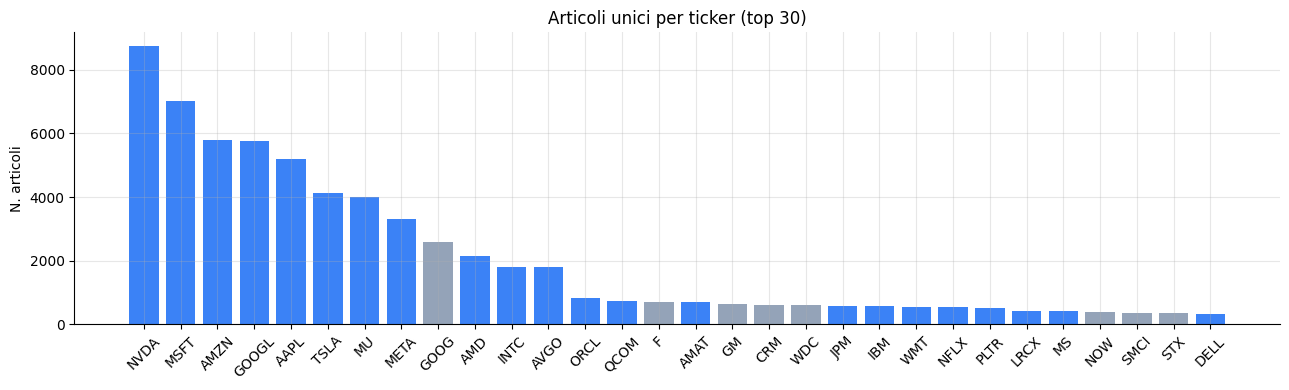

⚠ Ticker tracciati senza articoli: ['^GSPC']


In [6]:
# Articoli per ticker (top 30 per leggibilità)
counts = df_t.groupby('ticker')['url'].nunique().sort_values(ascending=False)
top = counts.head(30)

fig, ax = plt.subplots(figsize=(13, 4))
colors = ['#3b82f6' if t in tracked else '#94a3b8' for t in top.index]
ax.bar(top.index, top.values, color=colors)
ax.set_title('Articoli unici per ticker (top 30)')
ax.set_ylabel('N. articoli')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Ticker tracciati senza nemmeno un articolo
no_articles = [t for t in tracked if t not in counts.index]
if no_articles:
    print(f'⚠ Ticker tracciati senza articoli: {no_articles}')
else:
    print('✓ Tutti i ticker hanno almeno un articolo')

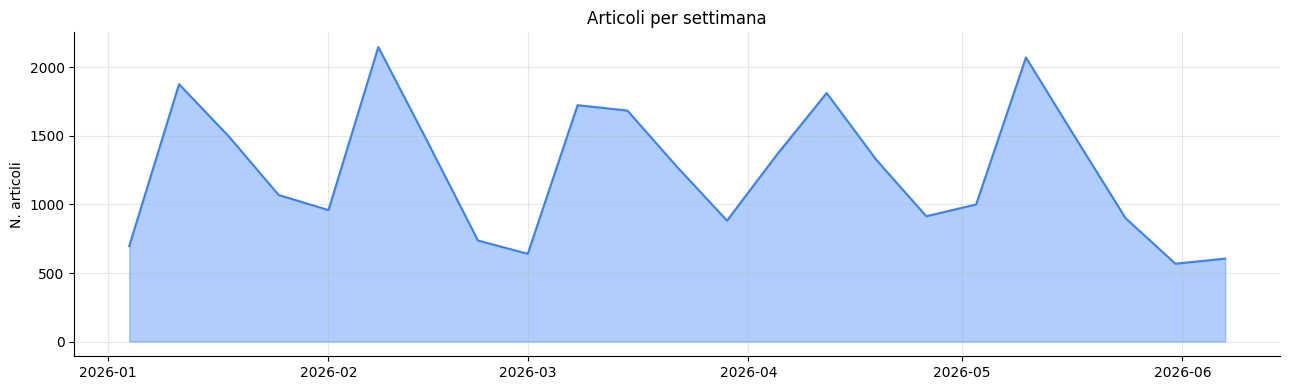

In [7]:
# Articoli per settimana (volume totale nel tempo)
weekly = df.set_index('date').resample('W')['url'].count()

fig, ax = plt.subplots()
ax.fill_between(weekly.index, weekly.values, alpha=0.4, color='#3b82f6')
ax.plot(weekly.index, weekly.values, color='#3b82f6')
ax.set_title('Articoli per settimana')
ax.set_ylabel('N. articoli')
plt.tight_layout()
plt.show()

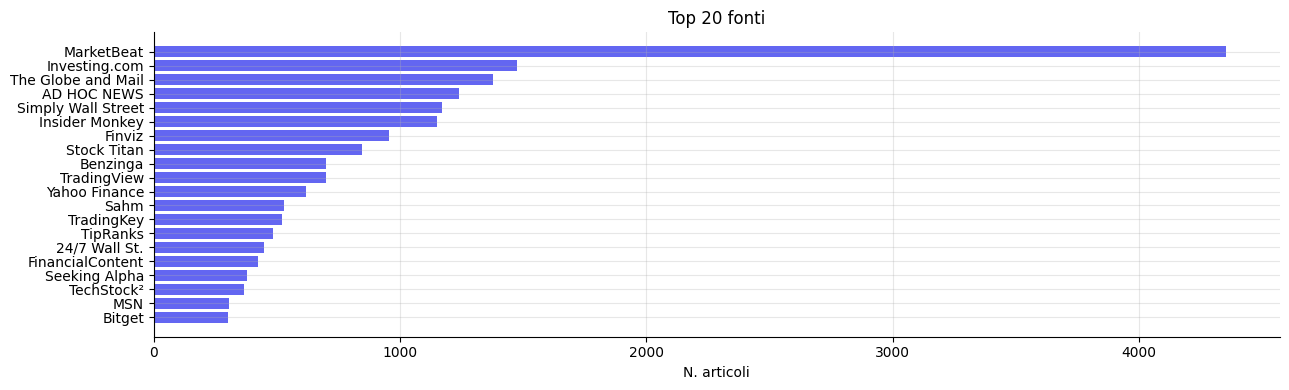

Fonti distinte totali: 1603


In [8]:
# Fonti più frequenti
top_sources = df['source'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 4))
ax.barh(top_sources.index[::-1], top_sources.values[::-1], color='#6366f1')
ax.set_title('Top 20 fonti')
ax.set_xlabel('N. articoli')
plt.tight_layout()
plt.show()

print(f'Fonti distinte totali: {df["source"].nunique()}')

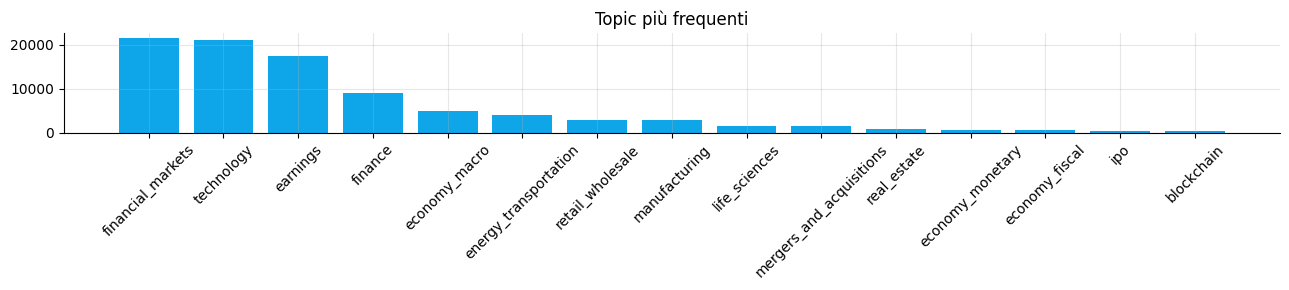

In [9]:
# Topic più frequenti
from collections import Counter
topic_counts = Counter(t for topics in df['topics'] for t in topics)
top_topics = pd.Series(topic_counts).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(13, 3))
ax.bar(top_topics.index, top_topics.values, color='#0ea5e9')
ax.set_title('Topic più frequenti')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3. Sentiment

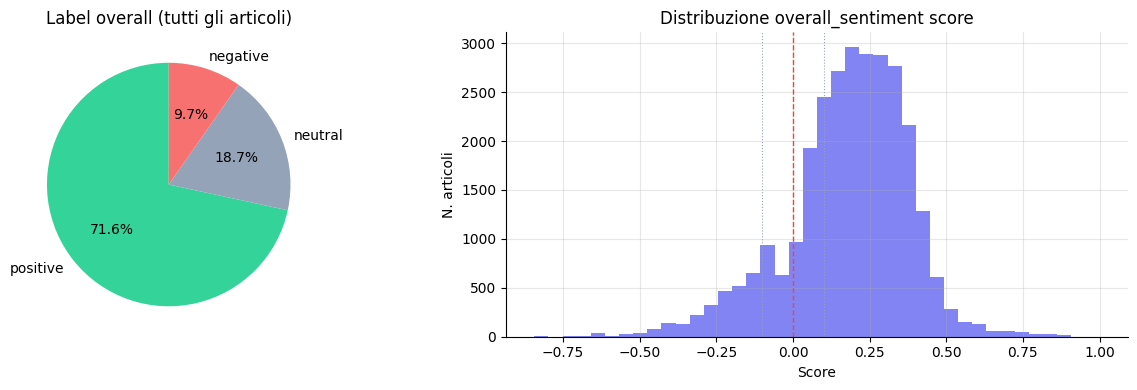

Score medio: 0.1794
Score mediano: 0.2020
Articoli con score == 0.000: 11


In [10]:
# Distribuzione label overall
label_counts = df['overall_label'].value_counts()
colors_map = {'positive': '#34d399', 'neutral': '#94a3b8', 'negative': '#f87171'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Torta
axes[0].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=[colors_map.get(l, '#94a3b8') for l in label_counts.index],
    autopct='%1.1f%%', startangle=90
)
axes[0].set_title('Label overall (tutti gli articoli)')

# Istogramma score
axes[1].hist(df['overall_sentiment'], bins=40, color='#6366f1', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='#ef4444', linewidth=1, linestyle='--')
axes[1].axvline(0.1, color='#94a3b8', linewidth=0.8, linestyle=':')
axes[1].axvline(-0.1, color='#94a3b8', linewidth=0.8, linestyle=':')
axes[1].set_title('Distribuzione overall_sentiment score')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('N. articoli')

plt.tight_layout()
plt.show()

print(f'Score medio: {df["overall_sentiment"].mean():.4f}')
print(f'Score mediano: {df["overall_sentiment"].median():.4f}')
print(f'Articoli con score == 0.000: {(df["overall_sentiment"] == 0.0).sum()}')

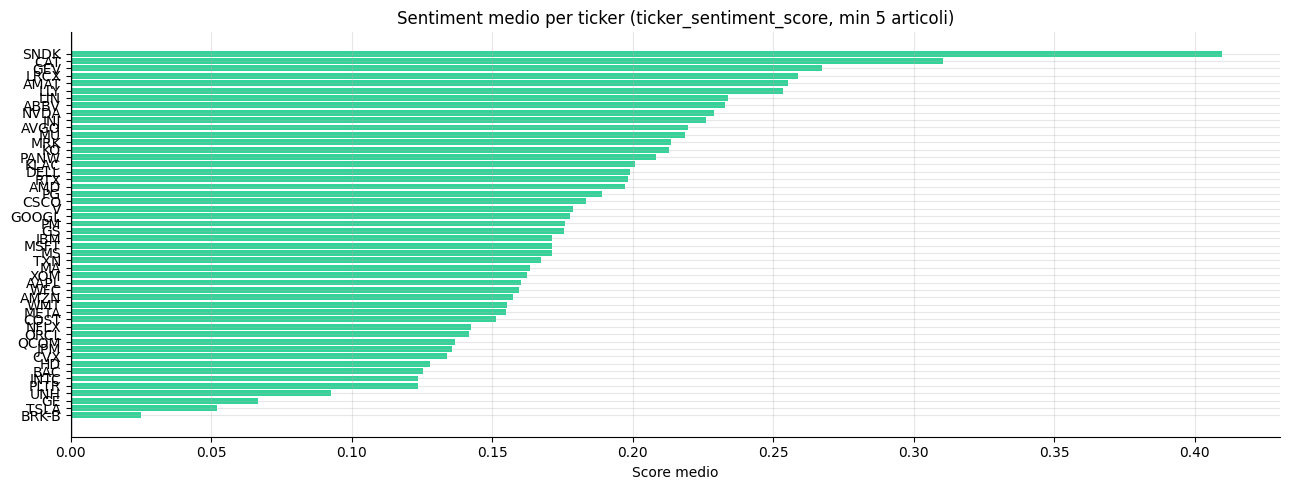

In [11]:
# Sentiment medio per ticker (ticker tracciati, almeno 5 articoli)
ticker_sent = (
    df_t[df_t['ticker'].isin(tracked)]
    .groupby('ticker')['sentiment']
    .agg(['mean', 'count'])
    .query('count >= 5')
    .sort_values('mean')
)

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ['#f87171' if v < 0 else '#34d399' for v in ticker_sent['mean']]
ax.barh(ticker_sent.index, ticker_sent['mean'], color=bar_colors)
ax.axvline(0, color='#1e293b', linewidth=1)
ax.set_title('Sentiment medio per ticker (ticker_sentiment_score, min 5 articoli)')
ax.set_xlabel('Score medio')
plt.tight_layout()
plt.show()

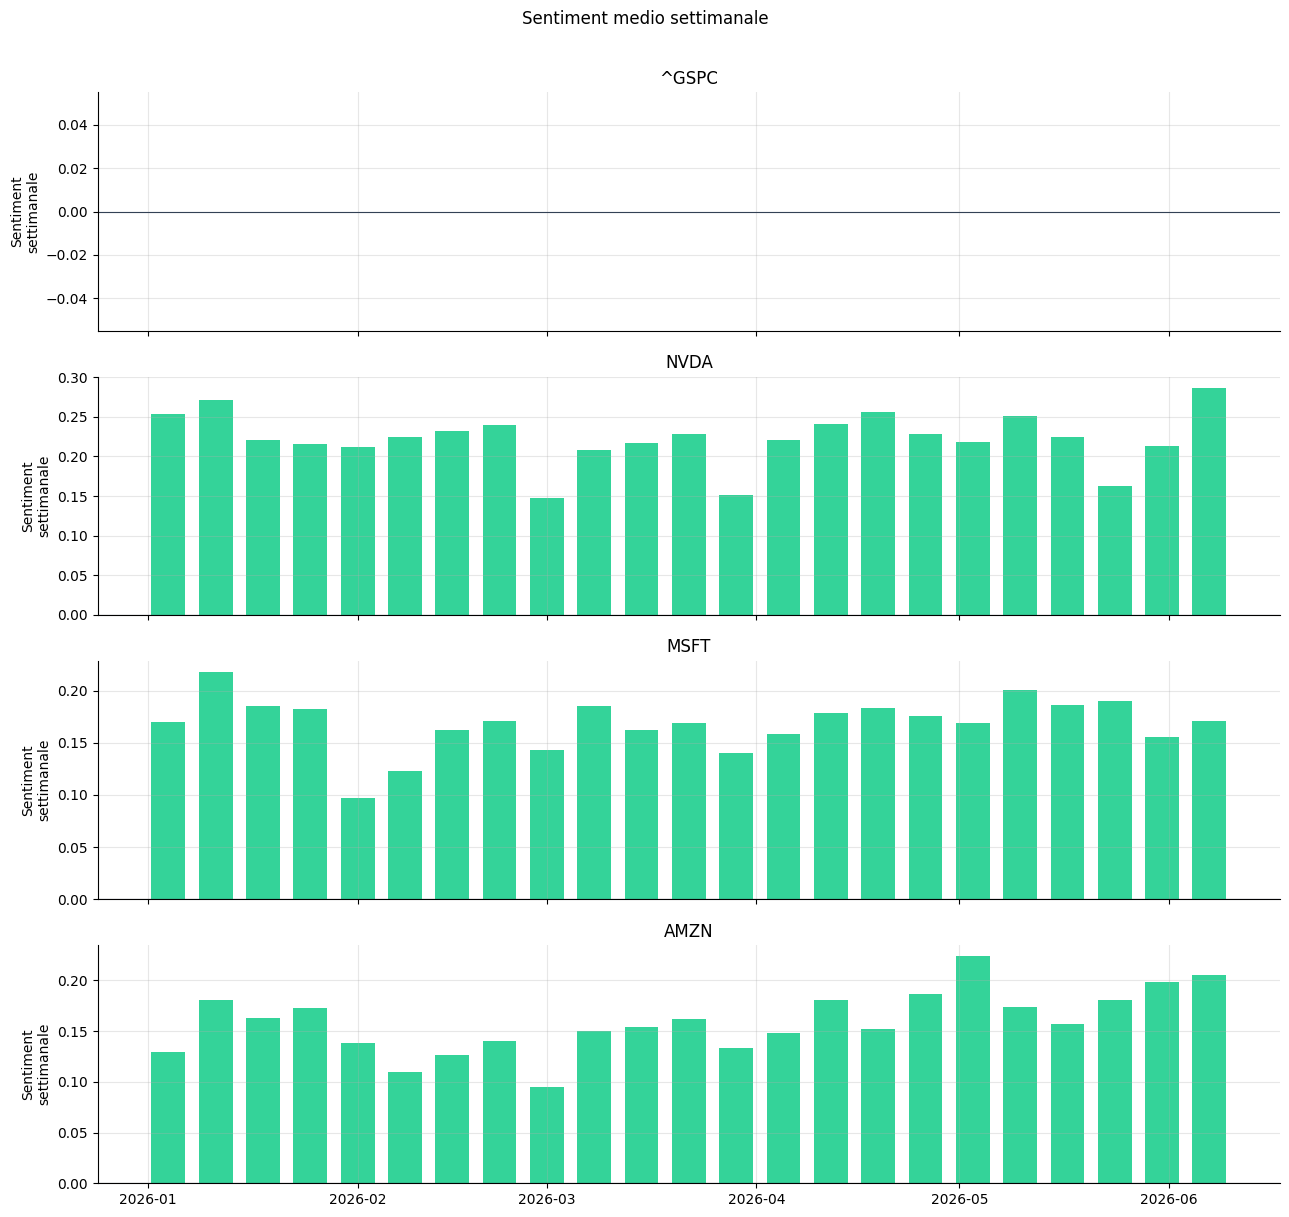

In [12]:
# Evoluzione temporale sentiment — ^GSPC e top 4 per volume
top4 = counts[counts.index.isin(tracked)].head(4).index.tolist()
focus_tickers = [market_index] + [t for t in top4 if t != market_index][:3]

fig, axes = plt.subplots(len(focus_tickers), 1, figsize=(13, 3 * len(focus_tickers)), sharex=True)
if len(focus_tickers) == 1:
    axes = [axes]

for ax, ticker in zip(axes, focus_tickers):
    sub = df_t[df_t['ticker'] == ticker].set_index('date').resample('W')['sentiment'].mean()
    colors_bar = ['#34d399' if v >= 0 else '#f87171' for v in sub.values]
    ax.bar(sub.index, sub.values, color=colors_bar, width=5)
    ax.axhline(0, color='#334155', linewidth=0.8)
    ax.set_ylabel('Sentiment\nsettimanale')
    ax.set_title(ticker)

plt.suptitle('Sentiment medio settimanale', y=1.01)
plt.tight_layout()
plt.show()

## 4. Prezzi e rendimenti

In [13]:
# Riepilogo copertura prezzi per ticker
summary_rows = []
for ticker, df_p in prices_frames.items():
    returns = df_p['return'].dropna()
    summary_rows.append({
        'ticker':   ticker,
        'giorni':   len(df_p),
        'da':       df_p['date'].min().date(),
        'a':        df_p['date'].max().date(),
        'ret_mean': round(returns.mean() * 100, 3),
        'ret_std':  round(returns.std() * 100, 3),
        'NaN_ret':  df_p['return'].isna().sum(),
    })

summary = pd.DataFrame(summary_rows).sort_values('giorni', ascending=False)
display(summary)

,ticker,giorni,da,a,ret_mean,ret_std,NaN_ret
0,NVDA,104,2026-01-02,2026-06-02,0.188,2.354,1
1,AAPL,104,2026-01-02,2026-06-02,0.160,1.525,1
2,MSFT,104,2026-01-02,2026-06-02,-0.041,2.091,1
3,AMZN,104,2026-01-02,2026-06-02,0.139,1.921,1
4,AVGO,104,2026-01-02,2026-06-02,0.352,2.613,1
5,GOOGL,104,2026-01-02,2026-06-02,0.154,1.956,1
6,META,104,2026-01-02,2026-06-02,-0.050,2.520,1
7,MU,104,2026-01-02,2026-06-02,1.308,4.998,1
8,TSLA,104,2026-01-02,2026-06-02,-0.003,2.453,1
9,AMD,104,2026-01-02,2026-06-02,0.927,4.549,1


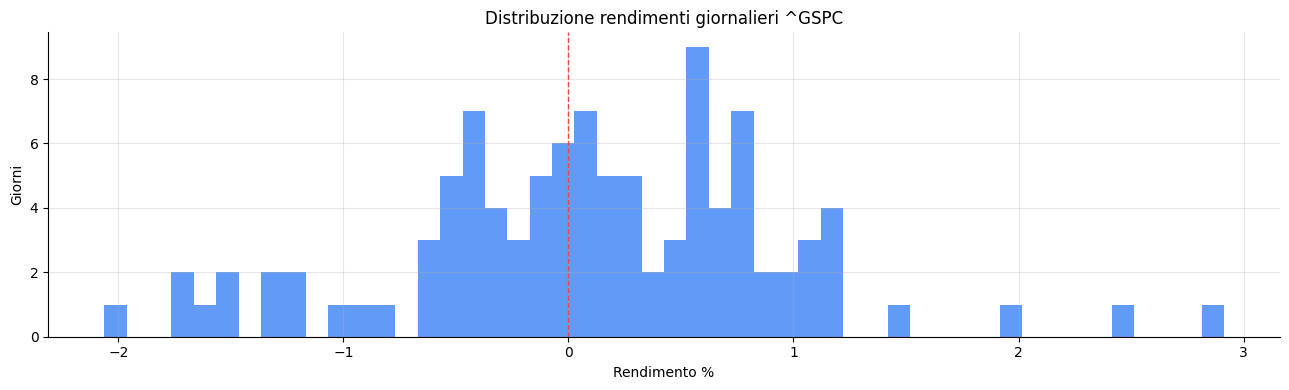

Media: 0.105%  |  Std: 0.849%
Min: -2.063%  |  Max: 2.913%


In [14]:
# Distribuzione rendimenti giornalieri — ^GSPC
ret_gspc = prices_frames[market_index]['return'].dropna() * 100

fig, ax = plt.subplots()
ax.hist(ret_gspc, bins=50, color='#3b82f6', edgecolor='none', alpha=0.8)
ax.axvline(0, color='#ef4444', linewidth=1, linestyle='--')
ax.set_title(f'Distribuzione rendimenti giornalieri {market_index}')
ax.set_xlabel('Rendimento %')
ax.set_ylabel('Giorni')
plt.tight_layout()
plt.show()

print(f'Media: {ret_gspc.mean():.3f}%  |  Std: {ret_gspc.std():.3f}%')
print(f'Min: {ret_gspc.min():.3f}%  |  Max: {ret_gspc.max():.3f}%')

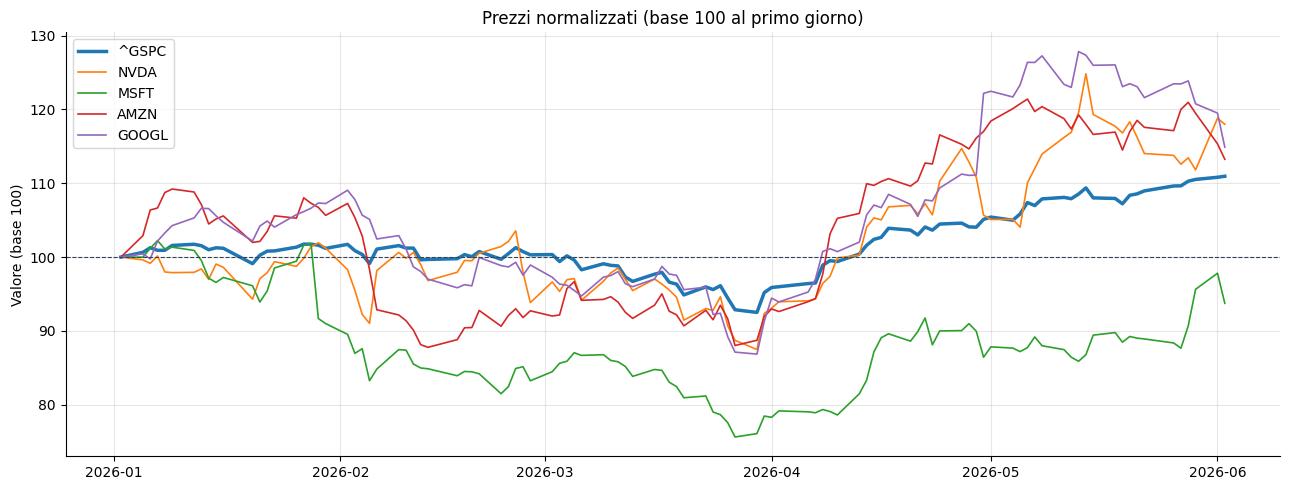

In [15]:
# Prezzi normalizzati a 100 — confronto tra top ticker per volume news
focus = [market_index] + [t for t in top4 if t != market_index and t in prices_frames][:4]

fig, ax = plt.subplots(figsize=(13, 5))
for ticker in focus:
    df_p = prices_frames[ticker].set_index('date')['close']
    normalized = df_p / df_p.iloc[0] * 100
    lw = 2.5 if ticker == market_index else 1.2
    ax.plot(normalized.index, normalized.values, label=ticker, linewidth=lw)

ax.axhline(100, color='#334155', linewidth=0.8, linestyle='--')
ax.set_title('Prezzi normalizzati (base 100 al primo giorno)')
ax.set_ylabel('Valore (base 100)')
ax.legend()
plt.tight_layout()
plt.show()

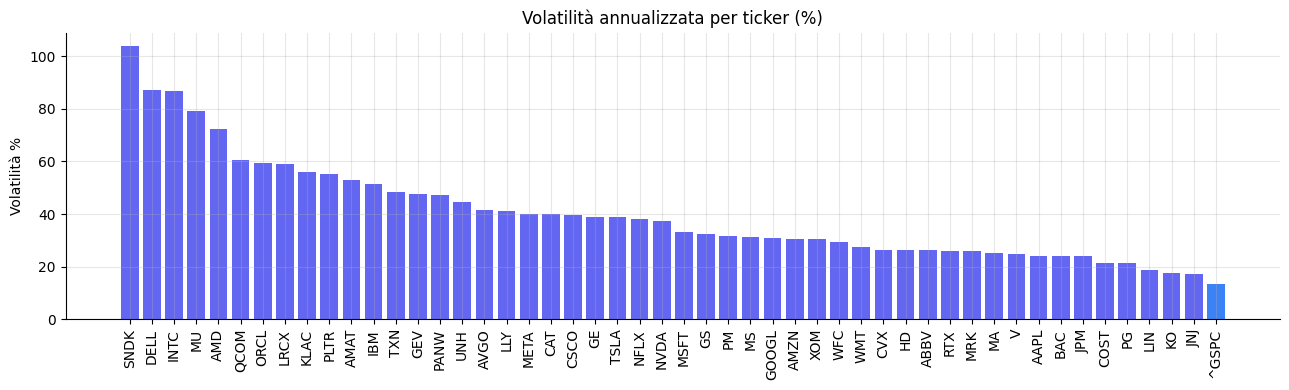

In [16]:
# Volatilità annualizzata per ticker (std rendimenti * sqrt(252))
vol = {
    t: df_p['return'].dropna().std() * (252 ** 0.5) * 100
    for t, df_p in prices_frames.items()
}
vol_s = pd.Series(vol).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(13, 4))
bar_colors = ['#3b82f6' if t == market_index else '#6366f1' for t in vol_s.index]
ax.bar(vol_s.index, vol_s.values, color=bar_colors)
ax.set_title('Volatilità annualizzata per ticker (%)')
ax.set_ylabel('Volatilità %')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## 5. Sanity check / anomalie

In [17]:
print('=== Articoli ===')
print(f'Totale                      : {len(df)}')
print(f'URL duplicati               : {df["url"].duplicated().sum()}')
print(f'URL vuoti                   : {(df["url"] == "").sum()}')
print(f'Senza ticker_sentiment      : {(df["n_tickers"] == 0).sum()}')
print(f'Score overall == 0.000      : {(df["overall_sentiment"] == 0.0).sum()}')

print('\n=== Ticker nelle news ===')
news_tickers = set(df_t['ticker'].unique())
unexpected = news_tickers - set(tracked)
print(f'Ticker distinti negli articoli: {len(news_tickers)}')
if unexpected:
    top_unexp = df_t[df_t['ticker'].isin(unexpected)]['ticker'].value_counts().head(10)
    print(f'Non in tickers.json (top 10):')
    for t, c in top_unexp.items():
        print(f'  {t}: {c}')

print('\n=== Prezzi ===')
for ticker, df_p in prices_frames.items():
    gaps = df_p['return'].isna().sum() - 1  # il primo giorno ha sempre return=None
    if gaps > 0:
        print(f'⚠ {ticker}: {gaps} rendimenti NaN (possibili gap nel dataset)')
print('✓ Check completato')

=== Articoli ===
Totale                      : 28677
URL duplicati               : 0
URL vuoti                   : 0
Senza ticker_sentiment      : 0
Score overall == 0.000      : 11

=== Ticker nelle news ===
Ticker distinti negli articoli: 4050
Non in tickers.json (top 10):
  GOOG: 2595
  F: 714
  GM: 644
  CRM: 613
  WDC: 607
  NOW: 388
  SMCI: 360
  STX: 355
  ADBE: 314
  UBER: 304

=== Prezzi ===
✓ Check completato


In [18]:
# Articoli senza ticker_sentiment — mostra i primi 5
no_ts = [a for a in articles if not a.get('all_tickers')]
if no_ts:
    print(f'{len(no_ts)} articoli senza ticker_sentiment. Primi 5:')
    for a in no_ts[:5]:
        print(f'  [{a["date"]}] {a["headline"][:80]}')
else:
    print('✓ Tutti gli articoli hanno almeno un ticker_sentiment')

✓ Tutti gli articoli hanno almeno un ticker_sentiment


In [19]:
# Allineamento temporale: prezzi vs news per ^GSPC
if market_index in prices_frames:
    price_dates = set(prices_frames[market_index]['date'].dt.date.astype(str))
    news_dates  = set(df[df['date'] >= prices_frames[market_index]['date'].min()]['date'].dt.date.astype(str))
    news_only   = news_dates - price_dates
    print(f'Date con news ma senza prezzo {market_index}: {len(news_only)}')
    if news_only:
        print(f'  (es. weekend/festivi: {sorted(news_only)[:5]})')

Date con news ma senza prezzo ^GSPC: 48
  (es. weekend/festivi: ['2026-01-03', '2026-01-04', '2026-01-10', '2026-01-11', '2026-01-17'])


In [20]:
TICKER = 'NVDA'

nvda = df_t[df_t['ticker'] == TICKER].sort_values('date', ascending=False)
seen = set()
results = []
for _, row in nvda.iterrows():
    if row['url'] not in seen:
        seen.add(row['url'])
        a = next(a for a in articles if a['url'] == row['url'])
        results.append({'date': row['date'].date(), 'sentiment': row['sentiment'],
                        'relevance': row['relevance'], 'label': row['label'],
                        'headline': a['headline'], 'source': a['source']})
    if len(results) == 5:
        break

for r in results:
    color = '\033[92m' if r['label'] == 'positive' else '\033[91m' if r['label'] == 'negative' else '\033[90m'
    reset = '\033[0m'
    print(f"{color}[{r['date']}]  {r['label']:8s}  score={r['sentiment']:+.3f}  rel={r['relevance']:.2f}{reset}")
    print(f"  {r['headline']}")
    print(f"  — {r['source']}\n")

[2026-06-02]  positive  score=+0.129  rel=0.66
  Rambus Faces Downside Risk as Memory Chip Momentum Weakens
  — 24/7 Wall St.

[2026-06-02]  positive  score=+0.204  rel=0.62
  Analysts Offer Insights on Technology Companies: Advanced Micro Devices (AMD), DigitalOcean Holdings (DOCN) and Fidelity National Info (FIS)
  — The Globe and Mail

[2026-06-02]  positive  score=+0.301  rel=0.57
  Norges Bank Takes Position in Celestica, Inc. $CLS
  — MarketBeat

[2026-06-02]  positive  score=+0.526  rel=0.65
  Why is Generac stock surging today?
  — Investing.com

[2026-06-02]  positive  score=+0.302  rel=0.67
  Why is STMicroelectronics stock surging today?
  — Investing.com

